# Notebook A: Customer Segmentation Analysis
**Analisis Perilaku Pengguna (Behavioral Matrix) & Wasted Value untuk Strategi Produk Baru**

---

### Identitas Anggota
* **Nama:** Aisyah Berlianti Afriandi (Cia)
* **NIM:** 255150700111022
* **Program Studi:** Teknologi Informasi

* **GitHub Repository:** [Telecom-Churn-Rate_Kelompok-2](https://github.com/AIU7AgrataEleigh/Telecom-Churn-Rate_Kelompok-2)
* **Dataset :**
Telecom Customer Churn Feature Engineering Dataset
---

### Fokus Variabel
1. `internet_usage_gb_capped` (Aktivitas Data)
2. `call_minutes_capped` (Aktivitas Telepon)
3. `monthly_bill_capped` (Sensitivitas Harga & Beban Tagihan)
4. `churn` (Indikator Kehilangan Pelanggan)

---

### Objektif Analisis (Specific EDA)
1. **Behavioral Matrix:** Membagi pelanggan ke dalam 4 kuadran perilaku berdasarkan nilai median (Fokus utama: *The Digital Natives* - Internet Tinggi, Nelpon Rendah).
2. **Wasted Value Analysis:** Membuktikan adanya "nilai hangus" di mana pelanggan terpaksa membayar fasilitas telepon yang tidak mereka gunakan.
3. **Churn Correlation:** Memvalidasi hipotesis apakah ketidaksesuaian paket ini memicu tingginya tingkat *churn* pada segmen target.

---

###  To-Do List (Alur Kerja)
1. **Step 1: Panggil Dataset & Import Library.** Memastikan data bersih dari folder GitHub siap diolah.
2. **Step 2: Cek Korelasi Awal.** Melihat hubungan antara penggunaan internet, telepon, dan tagihan bulanan terhadap peluang `churn`.
3. **Step 3: Membuat Segmentasi Pelanggan (Behavioral).** Membagi pelanggan ke dalam kuadran menggunakan nilai *median* untuk mencari target khusus: **Internet Tinggi, tapi Nelpon Rendah**.
4. **Step 4: Analisis Wasted Value & Churn.** Membuktikan apakah segmen target tersebut membayar tagihan terlalu mahal dan lebih rentan kabur (*churn*).

# 1. Pendahuluan

Notebook ini bertujuan melakukan analisis Customer Segmentation terhadap pelanggan perusahaan telekomunikasi menggunakan dataset **Telecom Customer Churn Feature Engineering Dataset**.

Analisis difokuskan pada tiga variabel utama, yaitu:

- internet_usage_gb
- call_minutes
- monthly_bill

Ketiga variabel tersebut digunakan untuk mengidentifikasi pola penggunaan layanan pelanggan sehingga dapat dibentuk beberapa segmen pelanggan berdasarkan karakteristik penggunaannya.

Hasil segmentasi diharapkan mampu memberikan insight mengenai perilaku pelanggan, mengidentifikasi segmen dengan nilai bisnis tertinggi maupun risiko churn terbesar, serta menjadi dasar penyusunan rekomendasi produk dan strategi retensi pelanggan.

# 2. Import Library & Load Clean Dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Tarik data bersih langsung dari GitHub
url = 'https://raw.githubusercontent.com/AIU7AgrataEleigh/Telecom-Churn-Rate_Kelompok-2/main/data/telecom_clean%20(2).csv'
df = pd.read_csv(url)

# Melihat  5 baris data teratas
df.head()

,gender,churn,monthly_bill_capped,internet_usage_gb_capped,call_minutes_capped,support_tickets_capped,tenure_months,financial_risk,education_level_encoded,contract_type_encoded,...,city_Gujranwala,city_Hyderabad,city_Islamabad,city_Karachi,city_Lahore,city_Multan,city_Peshawar,city_Quetta,city_Rawalpindi,city_Sialkot
0,1,0,10049.0,5.8,52.0,1,91,0,2,1,...,0,0,0,0,0,1,0,0,0,0
1,0,0,2752.0,11.9,22.0,2,91,0,3,1,...,0,0,0,0,0,0,1,0,0,0
2,1,0,3155.0,40.0,87.0,0,91,0,1,0,...,1,0,0,0,0,0,0,0,0,0
3,1,0,5859.0,8.5,147.0,2,90,0,1,1,...,0,0,0,0,1,0,0,0,0,0
4,0,0,5106.0,3.3,183.0,0,90,0,0,2,...,0,1,0,0,0,0,0,0,0,0


Library pandas digunakan untuk manipulasi data, numpy untuk operasi numerik, sedangkan matplotlib dan seaborn digunakan dalam proses visualisasi data sehingga pola pelanggan dapat diamati secara lebih jelas.

# 3. Validasi Dataset


In [ ]:
print(df.shape)

df.info()

df.describe()


(1200, 42)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 42 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   gender                        1200 non-null   int64  
 1   churn                         1200 non-null   int64  
 2   monthly_bill_capped           1200 non-null   float64
 3   internet_usage_gb_capped      1200 non-null   float64
 4   call_minutes_capped           1200 non-null   float64
 5   support_tickets_capped        1200 non-null   int64  
 6   tenure_months                 1200 non-null   int64  
 7   financial_risk                1200 non-null   int64  
 8   education_level_encoded       1200 non-null   int64  
 9   contract_type_encoded         1200 non-null   int64  
 10  emp_Employed                  1200 non-null   bool   
 11  emp_Retired                   1200 non-null   bool   
 12  emp_Self-Employed             1200 non-null   bool 

,gender,churn,monthly_bill_capped,internet_usage_gb_capped,call_minutes_capped,support_tickets_capped,tenure_months,financial_risk,education_level_encoded,contract_type_encoded,...,city_Gujranwala,city_Hyderabad,city_Islamabad,city_Karachi,city_Lahore,city_Multan,city_Peshawar,city_Quetta,city_Rawalpindi,city_Sialkot
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,...,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,0.502500,0.350000,5709.496250,19.960667,179.851250,1.191667,70.600000,0.019167,1.779167,0.813333,...,0.095833,0.089167,0.081667,0.083333,0.090000,0.094167,0.090000,0.099167,0.096667,0.094167
std,0.500202,0.477168,3226.473957,11.561477,96.839563,1.077450,11.552108,0.137168,1.078441,0.852894,...,0.294485,0.285103,0.273970,0.276501,0.286301,0.292182,0.286301,0.299010,0.295627,0.292182
min,0.000000,0.000000,710.000000,1.100000,14.000000,0.000000,51.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,3291.750000,11.100000,106.000000,0.000000,61.000000,0.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,0.000000,4871.000000,17.800000,164.000000,1.000000,71.000000,0.000000,2.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,1.000000,7485.500000,26.700000,235.000000,2.000000,81.000000,0.000000,3.000000,2.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,13776.125000,50.100000,428.500000,5.000000,91.000000,1.000000,4.000000,2.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
missing = pd.DataFrame({
    "Missing Values": df.isna().sum(),
    "Persentase (%)": (df.isna().mean()*100).round(2)
})

missing

,Missing Values,Persentase (%)
gender,0,0.0
churn,0,0.0
monthly_bill_capped,0,0.0
internet_usage_gb_capped,0,0.0
call_minutes_capped,0,0.0
support_tickets_capped,0,0.0
tenure_months,0,0.0
financial_risk,0,0.0
education_level_encoded,0,0.0
contract_type_encoded,0,0.0


Berdasarkan hasil pemeriksaan, seluruh variabel memiliki jumlah missing value sebesar **0**. Hal ini menunjukkan bahwa dataset telah lengkap sehingga tidak diperlukan proses penanganan missing values seperti imputasi maupun penghapusan data. Dengan demikian, seluruh 1.200 data pelanggan dapat digunakan pada tahap analisis berikutnya.

In [ ]:
df.head()

,gender,churn,monthly_bill_capped,internet_usage_gb_capped,call_minutes_capped,support_tickets_capped,tenure_months,financial_risk,education_level_encoded,contract_type_encoded,...,city_Gujranwala,city_Hyderabad,city_Islamabad,city_Karachi,city_Lahore,city_Multan,city_Peshawar,city_Quetta,city_Rawalpindi,city_Sialkot
0,1,0,10049.0,5.8,52.0,1,91,0,2,1,...,0,0,0,0,0,1,0,0,0,0
1,0,0,2752.0,11.9,22.0,2,91,0,3,1,...,0,0,0,0,0,0,1,0,0,0
2,1,0,3155.0,40.0,87.0,0,91,0,1,0,...,1,0,0,0,0,0,0,0,0,0
3,1,0,5859.0,8.5,147.0,2,90,0,1,1,...,0,0,0,0,1,0,0,0,0,0
4,0,0,5106.0,3.3,183.0,0,90,0,0,2,...,0,1,0,0,0,0,0,0,0,0


Validasi dilakukan untuk memastikan jumlah data, tipe data setiap atribut, serta statistik deskriptif awal. Untuk memastikan dataset siap digunakan pada tahap eksplorasi data.

# 4.  Eksplorasi Variabel Customer Segmentation

Eksplorasi bertujuan memahami karakteristik masing-masing variabel melalui statistika deskriptif sehingga dapat diketahui nilai pusat data, tingkat penyebaran, serta bentuk distribusinya sebelum dilakukan visualisasi dan proses segmentasi pelanggan.


## 4.1 Pemilihan Variabel
>Analisis customer segmentation difokuskan pada tiga atribut numerik yang merepresentasikan perilaku penggunaan layanan pelanggan, yaitu internet_usage_gb, call_minutes, dan monthly_bill. Ketiga variabel tersebut dipilih karena mampu menggambarkan intensitas penggunaan layanan serta kontribusi nilai ekonomi pelanggan terhadap perusahaan. Variabel churn turut disertakan sebagai variabel target untuk melihat hubungan antara karakteristik pelanggan dengan kecenderungan berhenti berlanggan

In [ ]:
segmentation = df[
[
"internet_usage_gb_capped",
"call_minutes_capped",
"monthly_bill_capped",
"churn"
]
]

segmentation.head()

,internet_usage_gb_capped,call_minutes_capped,monthly_bill_capped,churn
0,5.8,52.0,10049.0,0
1,11.9,22.0,2752.0,0
2,40.0,87.0,3155.0,0
3,8.5,147.0,5859.0,0
4,3.3,183.0,5106.0,0


Variabel internet_usage_gb digunakan untuk menggambarkan intensitas penggunaan internet pelanggan, call_minutes menunjukkan aktivitas komunikasi suara, sedangkan monthly_bill digunakan untuk merepresentasikan nilai ekonomi pelanggan terhadap perusahaan.

##4.2 Profil Statistik Variabel
>Karakteristik pusat digunakan untuk mengetahui nilai tipikal dari masing-masing variabel numerik sebelum dilakukan visualisasi data. Ukuran yang digunakan meliputi mean, median, dan mode.

Interpretasi
Range = menunjukkan rentang data
Variance = mengukur tingkat keragaman
Standar deviasi =  seberapa jauh data menyebar dari nilai rata-ratanya.
-> Semakin besar standar deviasi maka semakin beragam karakteristik pelanggan.

Business Insight
Variasi penggunaan layanan yang tinggi menunjukkan bahwa perusahaan memiliki pelanggan dengan perilaku yang sangat beragam sehingga strategi pemasaran tidak dapat disamaratakan untuk seluruh pelanggan.

In [ ]:
summary = pd.DataFrame(index=segmentation.columns)

summary["Mean"] = segmentation.mean(numeric_only=True)
summary["Median"] = segmentation.median(numeric_only=True)
summary["Mode"] = segmentation.mode().iloc[0]

summary["Minimum"] = segmentation.min(numeric_only=True)
summary["Maximum"] = segmentation.max(numeric_only=True)

summary["Range"] = (
    summary["Maximum"] -
    summary["Minimum"]
)

summary["Variance"] = segmentation.var(numeric_only=True)
summary["Std Dev"] = segmentation.std(numeric_only=True)

summary["Skewness"] = segmentation.skew(numeric_only=True)
summary["Kurtosis"] = segmentation.kurtosis(numeric_only=True)

summary = summary.round(3)

summary

,Mean,Median,Mode,Minimum,Maximum,Range,Variance,Std Dev,Skewness,Kurtosis
internet_usage_gb_capped,19.961,17.8,50.100,1.1,50.100,49.000,1.336680e+02,11.561,0.750,-0.010
call_minutes_capped,179.851,164.0,428.500,14.0,428.500,414.500,9.377901e+03,96.840,0.761,0.089
monthly_bill_capped,5709.496,4871.0,13776.125,710.0,13776.125,13066.125,1.041013e+07,3226.474,0.971,0.258
churn,0.350,0.0,0.000,0.0,1.000,1.000,2.280000e-01,0.477,0.630,-1.606


## 4.3 Visualisasi Distribusi Variabel
Setelah mengetahui karakteristik statistik dataset, langkah berikutnya adalah memvisualisasikan distribusi masing-masing variabel menggunakan histogram dan kurva Kernel Density Estimation (KDE). Visualisasi ini bertujuan melihat pola persebaran data secara lebih intuitif serta mengidentifikasi dominasi kelompok pelanggan berdasarkan perilaku penggunaan layanan.


###4.3.1 Distribusi Penggunaan Internet


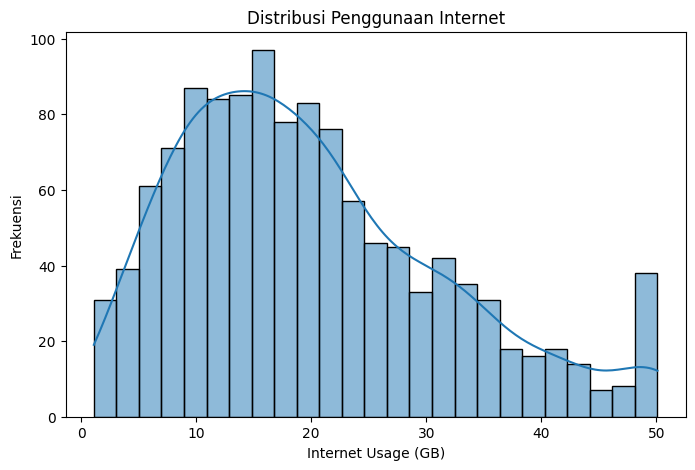

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    segmentation["internet_usage_gb_capped"],
    bins=25,
    kde=True
)

plt.title("Distribusi Penggunaan Internet")
plt.xlabel("Internet Usage (GB)")
plt.ylabel("Frekuensi")

plt.show()

### 4.3.2 Distribusi Durasi Telepon

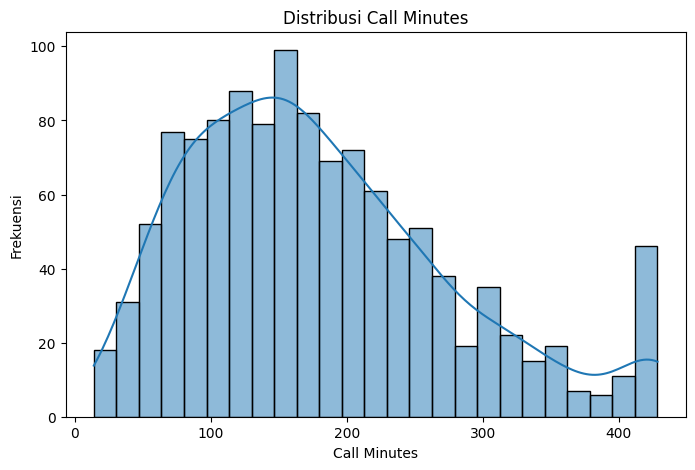

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    segmentation["call_minutes_capped"],
    bins=25,
    kde=True
)

plt.title("Distribusi Call Minutes")
plt.xlabel("Call Minutes")
plt.ylabel("Frekuensi")

plt.show()


###4.3.3 Distribusi Monthly Bill


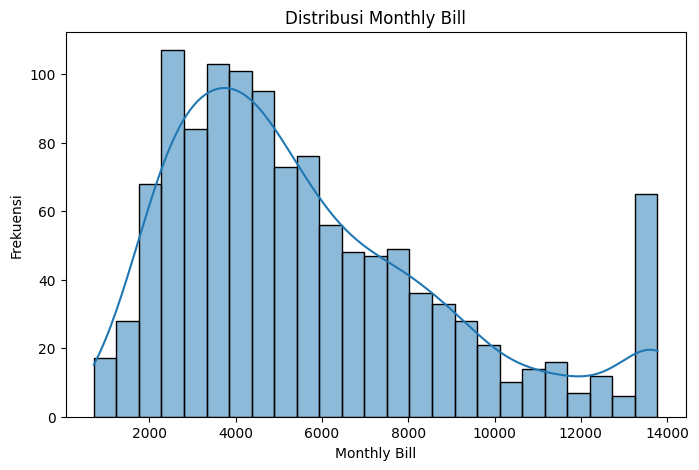

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    segmentation["monthly_bill_capped"],
    bins=25,
    kde=True
)

plt.title("Distribusi Monthly Bill")
plt.xlabel("Monthly Bill")
plt.ylabel("Frekuensi")

plt.show()

###4.3.4 Deteksi Outlier (Boxplot)


##4.4 Hubungan Antar Variabel
Analisis hubungan dilakukan menggunakan matriks korelasi dan scatter plot sehingga dapat diketahui apakah peningkatan salah satu variabel berkaitan dengan perubahan variabel lainnya.


###4.4.1 Correlation Heatmap

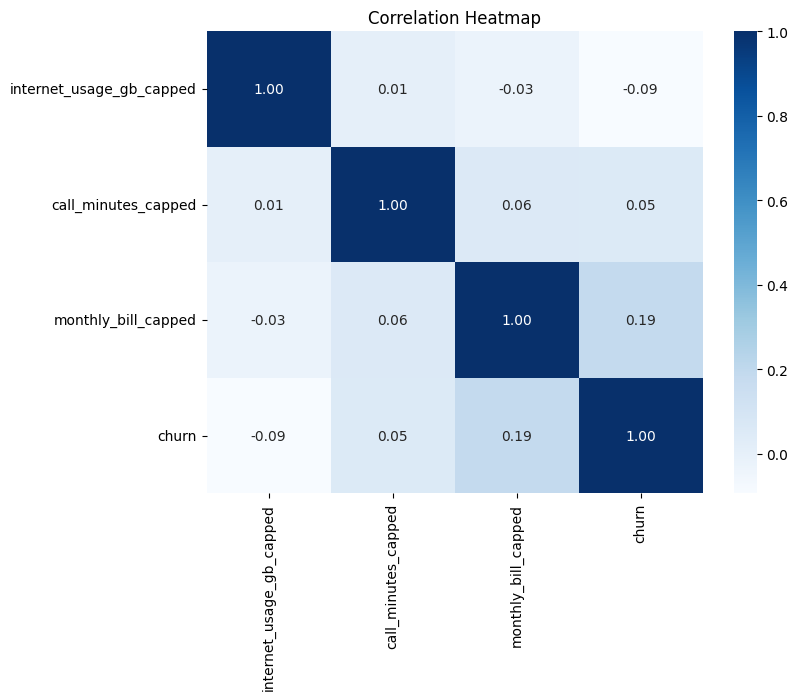

In [ ]:
plt.figure(figsize=(8,6))

sns.heatmap(
    segmentation.corr(numeric_only=True),
    annot=True,
    cmap="Blues",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

### 4.4.2 Scatter Plot


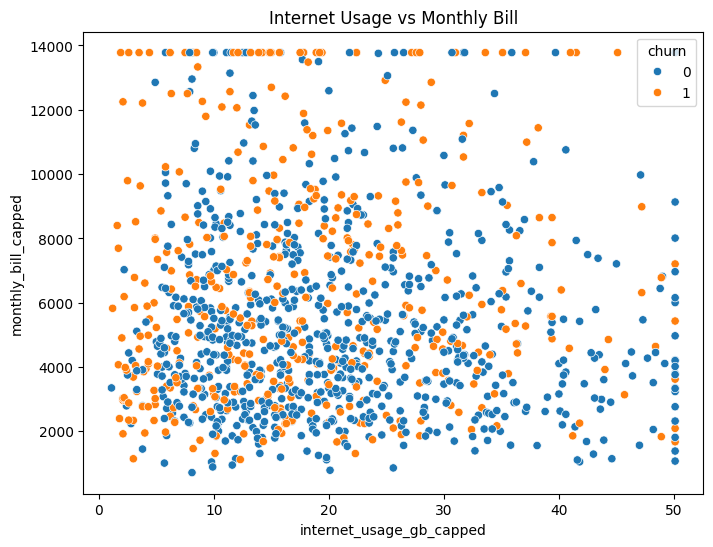

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=segmentation,
    x="internet_usage_gb_capped",
    y="monthly_bill_capped",
    hue="churn"
)

plt.title("Internet Usage vs Monthly Bill")

plt.show()

### 4.4.3 Pivot Analysis


In [ ]:
pivot_summary = segmentation.groupby("churn").agg({
    "internet_usage_gb_capped":"mean",
    "call_minutes_capped":"mean",
    "monthly_bill_capped":"mean"
}).round(2)

pivot_summary.index = ["Non-Churn","Churn"]

pivot_summary

,internet_usage_gb_capped,call_minutes_capped,monthly_bill_capped
Non-Churn,20.75,176.09,5270.75
Churn,18.49,186.83,6524.31


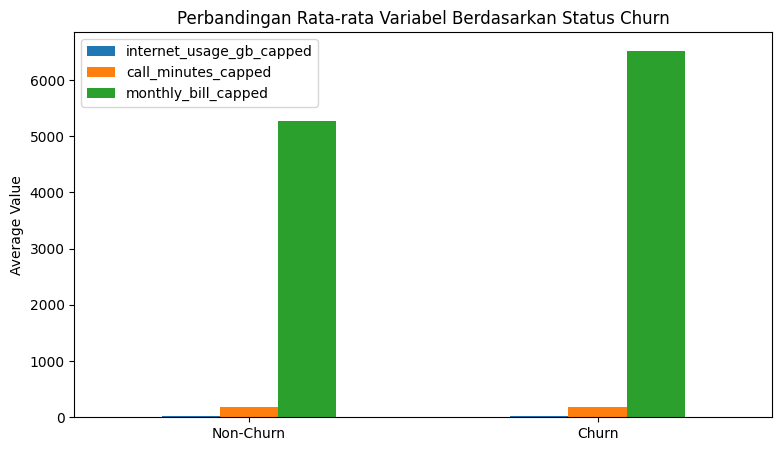

In [ ]:
pivot_summary.plot(
    kind="bar",
    figsize=(9,5)
)

plt.title("Perbandingan Rata-rata Variabel Berdasarkan Status Churn")
plt.ylabel("Average Value")
plt.xticks(rotation=0)

plt.show()

### 4.4.4 Analisis Outlier

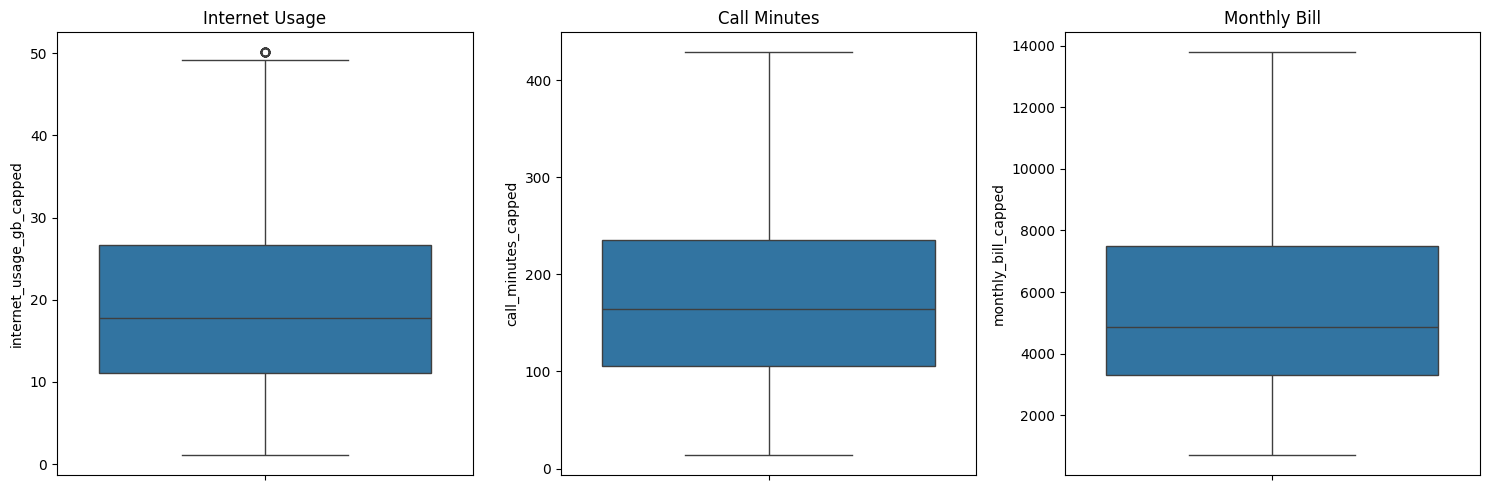

In [ ]:
fig, axes = plt.subplots(1,3,figsize=(15,5))

sns.boxplot(
    y=segmentation["internet_usage_gb_capped"],
    ax=axes[0]
)
axes[0].set_title("Internet Usage")

sns.boxplot(
    y=segmentation["call_minutes_capped"],
    ax=axes[1]
)
axes[1].set_title("Call Minutes")

sns.boxplot(
    y=segmentation["monthly_bill_capped"],
    ax=axes[2]
)
axes[2].set_title("Monthly Bill")

plt.tight_layout()

plt.show()

### 4.4.5 Pairplot

In [ ]:
pair_df = segmentation[
    [
        "internet_usage_gb_capped",
        "call_minutes_capped",
        "monthly_bill_capped",
        "churn"
    ]
]

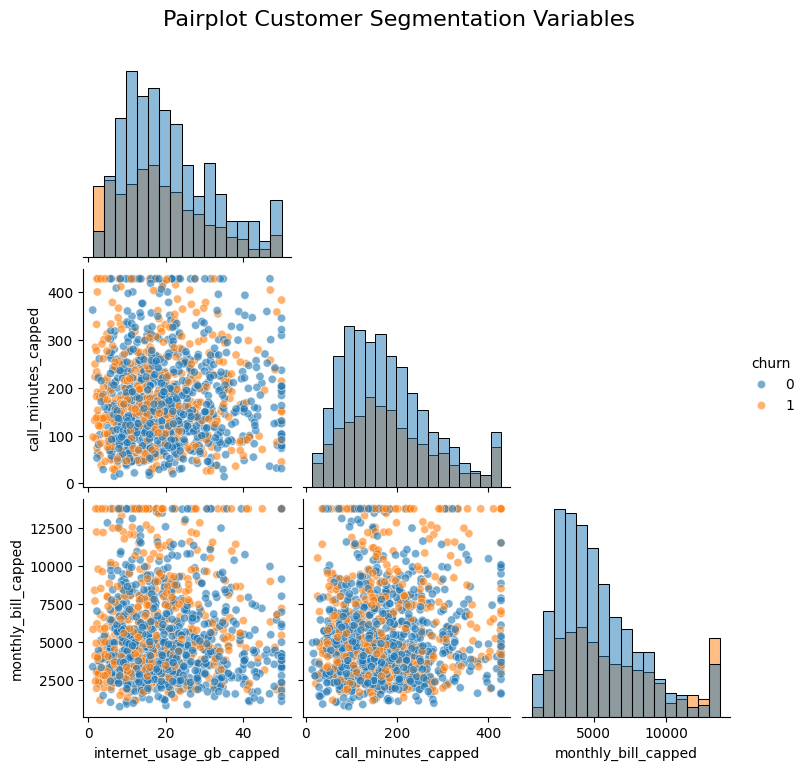

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(
    pair_df,
    vars=[
        "internet_usage_gb_capped",
        "call_minutes_capped",
        "monthly_bill_capped"
    ],
    hue="churn",
    diag_kind="hist",
    corner=True,
    plot_kws={
        "alpha":0.6,
        "s":35
    }
)

plt.suptitle(
    "Pairplot Customer Segmentation Variables",
    y=1.02,
    fontsize=16
)

plt.show()

#5. Customer Segmentation

#5.1 Membentuk Customer Persona
Segmentasi menghasilkan empat persona utama yang mewakili karakteristik perilaku pelanggan.

- 🚀 Power User
- 📱 Internet Enthusiast
- 📞 Traditional Communicator
- 🌱 Casual User

In [ ]:
# Menentukan nilai median sebagai batas segmentasi
internet_median = segmentation["internet_usage_gb_capped"].median()
call_median = segmentation["call_minutes_capped"].median()

print("Median Internet Usage :", internet_median)
print("Median Call Minutes   :", call_median)

Median Internet Usage : 17.8
Median Call Minutes   : 164.0


In [ ]:
def customer_segment(row):

    internet = row["internet_usage_gb_capped"]
    call = row["call_minutes_capped"]

    if internet >= internet_median and call >= call_median:
        return "Power User"

    elif internet >= internet_median and call < call_median:
        return "Internet Enthusiast"

    elif internet < internet_median and call >= call_median:
        return "Traditional Communicator"

    else:
        return "Casual User"



In [ ]:
segmentation["customer_segment"] = segmentation.apply(
    customer_segment,
    axis=1
)

segmentation[
    [
        "internet_usage_gb_capped",
        "call_minutes_capped",
        "customer_segment"
    ]
].head()

/tmp/ipykernel_2649/787532628.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  segmentation["customer_segment"] = segmentation.apply(


,internet_usage_gb_capped,call_minutes_capped,customer_segment
0,5.8,52.0,Casual User
1,11.9,22.0,Casual User
2,40.0,87.0,Internet Enthusiast
3,8.5,147.0,Casual User
4,3.3,183.0,Traditional Communicator


##Interpretasi
Setiap pelanggan  dikelompokkan ke dalam salah satu Customer Persona berdasarkan karakteristik penggunaan internet dan layanan telepon. Segmentasi ini menjadi dasar untuk menganalisis perilaku pelanggan, nilai bisnis, serta kecenderungan churn pada masing-masing kelompok.

## 5.2 Distribusi Custoemr Persona



In [ ]:
segment_count = (
    segmentation["customer_segment"]
    .value_counts()
    .reset_index()
)

segment_count.columns = ["Customer Persona","Jumlah Pelanggan"]

segment_count

,Customer Persona,Jumlah Pelanggan
0,Power User,304
1,Casual User,301
2,Internet Enthusiast,298
3,Traditional Communicator,297


###Visualisasi

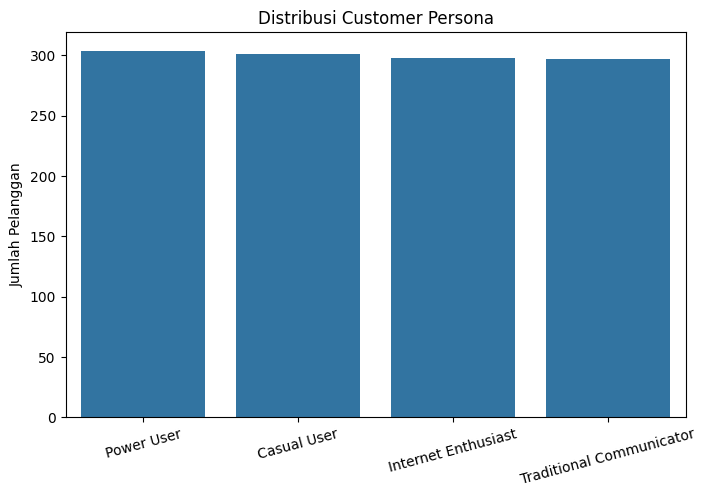

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=segmentation,
    x="customer_segment",
    order=segmentation["customer_segment"].value_counts().index
)

plt.title("Distribusi Customer Persona")
plt.xlabel("")
plt.ylabel("Jumlah Pelanggan")

plt.xticks(rotation=15)

plt.show()

##Interpretasi
Visualisasi menunjukkan proporsi masing-masing Customer Persona. Informasi ini memberikan gambaran mengenai kelompok pelanggan yang paling banyak dimiliki perusahaan sehingga strategi pemasaran dapat diprioritaskan pada segmen tertentu.

##Business Insight
Segmen dengan jumlah pelanggan terbesar merupakan pasar utama perusahaan, sedangkan segmen dengan jumlah pelanggan lebih kecil dapat menjadi target pengembangan produk khusus.

##5.3. Analisis Nilai Pelanggan

Selain melihat jumlah pelanggan, penting untuk mengetahui nilai ekonomi dari setiap Customer Persona.

Analisis dilakukan menggunakan rata-rata monthly_bill sebagai indikator kontribusi pendapatan dar

In [ ]:
revenue = (
segmentation
.groupby("customer_segment")["monthly_bill_capped"]
.mean()
.sort_values(ascending=False)
)

revenue

,monthly_bill_capped
customer_segment,
Traditional Communicator,5781.568182
Power User,5709.486431
Internet Enthusiast,5677.368289
Casual User,5670.199751


##Visualisasi

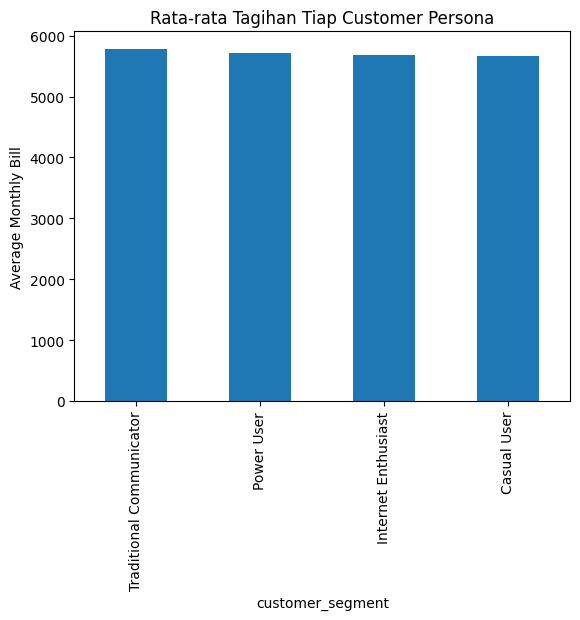

In [ ]:
revenue.plot(kind="bar")

plt.ylabel("Average Monthly Bill")

plt.title("Rata-rata Tagihan Tiap Customer Persona")

plt.show()

##Interpretasi
Nilai rata-rata monthly bill menggambarkan kontribusi pendapatan yang dihasilkan oleh masing-masing Customer Persona. Segmen dengan rata-rata tagihan tertinggi merupakan pelanggan bernilai tinggi yang perlu dipertahankan.

##Business Insight
Perusahaan dapat memprioritaskan strategi retensi pada Customer Persona dengan kontribusi pendapatan terbesar karena kehilangan pelanggan pada segmen tersebut akan memberikan dampak finansial yang lebih besar.

##5.4 Analaisis Package Missmatch


In [ ]:
persona_summary = (
    segmentation
    .groupby("customer_segment")
    .agg({
        "internet_usage_gb_capped": "mean",
        "call_minutes_capped": "mean",
        "monthly_bill_capped": "mean"
    })
    .round(2)
)

persona_summary

,internet_usage_gb_capped,call_minutes_capped,monthly_bill_capped
customer_segment,,,
Casual User,10.82,102.07,5670.20
Internet Enthusiast,29.34,105.42,5677.37
Power User,28.78,258.61,5709.49
Traditional Communicator,10.79,252.76,5781.57


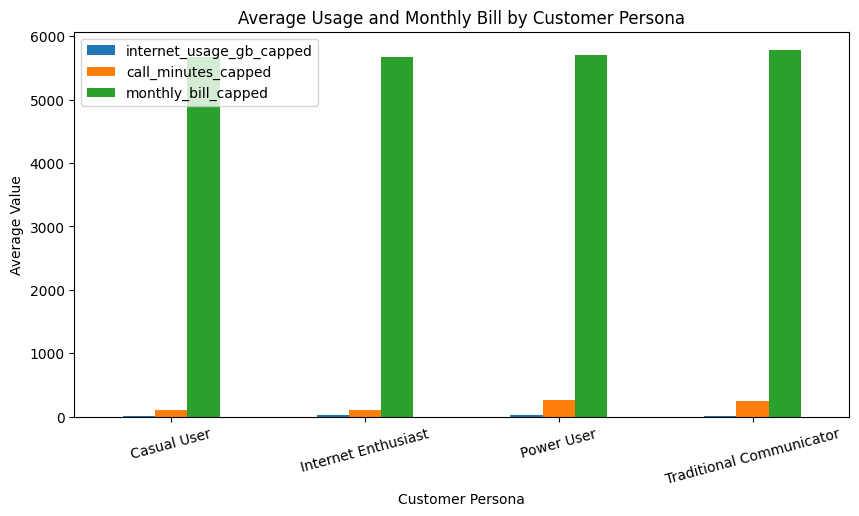

In [ ]:
ax = persona_summary.plot(
    kind="bar",
    figsize=(10,5)
)

ax.set_title("Average Usage and Monthly Bill by Customer Persona")
ax.set_xlabel("Customer Persona")
ax.set_ylabel("Average Value")

plt.xticks(rotation=15)

plt.show()

## 5.5.Analisis Churn Tiap Persona
mengetahui apakah setiap Customer Persona memiliki tingkat churn yang berbeda sehingga perusahaan dapat menentukan prioritas strategi retensi pelanggan.

In [ ]:
churn = (
segmentation
.groupby("customer_segment")["churn"]
.mean()*100
)

churn

,churn
customer_segment,
Casual User,36.544850
Internet Enthusiast,30.872483
Power User,33.223684
Traditional Communicator,39.393939


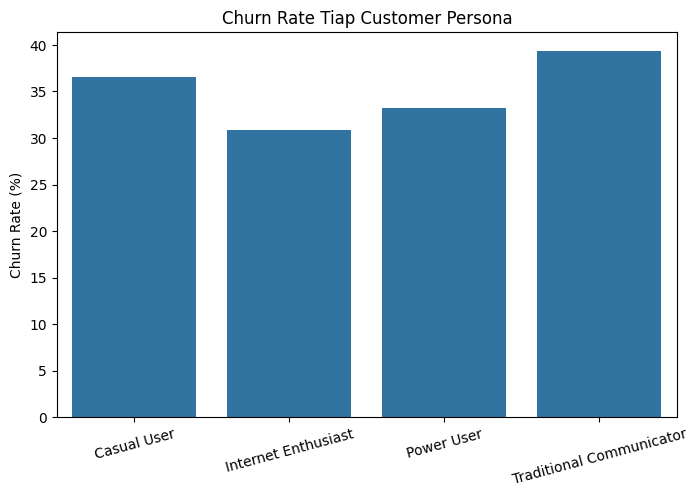

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
x=churn.index,
y=churn.values
)

plt.ylabel("Churn Rate (%)")

plt.xlabel("")

plt.title("Churn Rate Tiap Customer Persona")

plt.xticks(rotation=15)

plt.show()

##Intepretasi
Persentase churn menunjukkan tingkat pelanggan yang berhenti berlangganan pada masing-masing Customer Persona. Semakin tinggi persentase churn, semakin besar risiko kehilangan pelanggan pada segmen tersebut.

## Business Insight
Customer Persona dengan churn rate tertinggi menjadi prioritas utama dalam strategi retensi pelanggan, sedangkan segmen dengan churn rendah dapat dipertahankan melalui program loyalitas.

# 6. Insight Utama

Berdasarkan hasil eksplorasi data diperoleh beberapa insight penting:

1. Customer Persona berhasil mengelompokkan pelanggan berdasarkan perilaku penggunaan layanan.

2. Setiap Customer Persona memiliki karakteristik penggunaan internet dan telepon yang berbeda.

3. Nilai rata-rata tagihan bulanan berbeda pada setiap Customer Persona sehingga kontribusi terhadap pendapatan perusahaan juga berbeda.

4. Tingkat churn tidak sama pada setiap Customer Persona sehingga strategi retensi pelanggan perlu disesuaikan dengan karakteristik masing-masing segmen.

5. Pendekatan segmentasi pelanggan membantu perusahaan memahami perilaku pelanggan secara lebih terstruktur sehingga keputusan bisnis dapat dilakukan secara lebih tepat sasaran.

# 7. Rekomendasi Bisnis

Berdasarkan hasil analisis Customer Persona, beberapa rekomendasi yang dapat diberikan adalah:

### 🚀 Power User
- Menawarkan paket premium dengan kuota internet besar dan telepon unlimited.
- Memberikan program loyalitas agar pelanggan bernilai tinggi tetap bertahan.

### 📱 Internet Enthusiast
- Menawarkan paket streaming, gaming, dan internet unlimited.
- Mengurangi komposisi layanan telepon pada paket yang ditawarkan.

### 📞 Traditional Communicator
- Menawarkan paket telepon unlimited dengan tambahan kuota internet dasar.
- Mengembangkan layanan voice yang lebih kompetitif.

### 🌱 Casual User
- Memberikan paket hemat dengan biaya berlangganan yang lebih rendah.
- Menawarkan promosi atau diskon untuk meningkatkan intensitas penggunaan layanan.